A partir da imagem original obtenha as outras imagens conforme descrição
Desejamos separar linhas de círculos. Uma operação de abertura com um elemento estruturante na forma de círculo (definir o raio) faz essa tarefa. Gere uma imagem com os círculos e uma com as linhas

Passo 1: Extraindo círculos


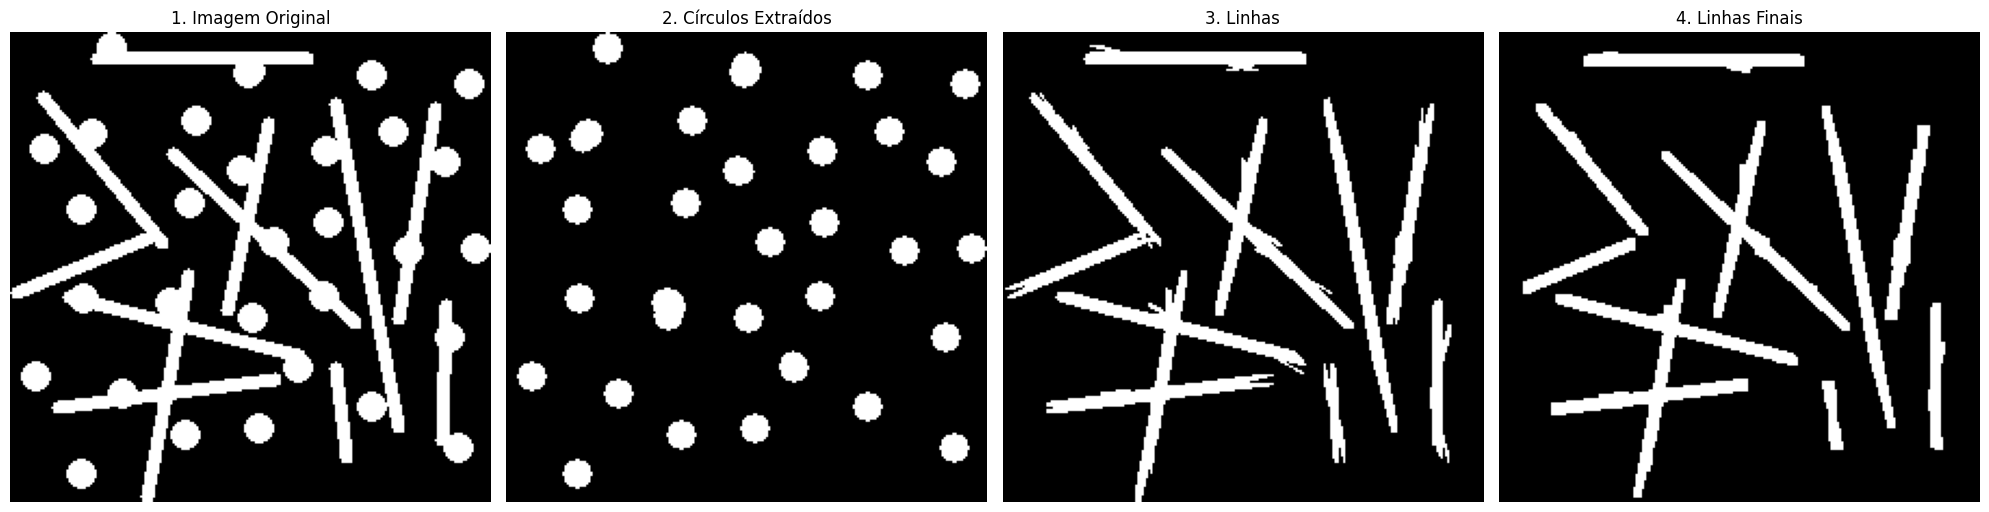

In [ ]:
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

# --- 1. Funções Morfológicas ---

def erosao(img, kernel):
    k_alt, k_larg = kernel.shape
    pad_y, pad_x = k_alt // 2, k_larg // 2
    img_pad = np.pad(img, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant', constant_values=0)
    img_erodida = np.zeros_like(img)
    soma_kernel = np.sum(kernel)
    img_bin = img_pad // 255
    linhas, colunas = img.shape
    for i in range(linhas):
        for j in range(colunas):
            regiao = img_bin[i:i+k_alt, j:j+k_larg]
            if regiao.shape == kernel.shape:
                if np.sum(regiao * kernel) == soma_kernel:
                    img_erodida[i, j] = 255
    return img_erodida

def dilatacao(img, kernel):
    k_alt, k_larg = kernel.shape
    pad_y, pad_x = k_alt // 2, k_larg // 2
    img_pad = np.pad(img, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant', constant_values=0)
    img_dilatada = np.zeros_like(img)
    img_bin = img_pad // 255
    linhas, colunas = img.shape
    for i in range(linhas):
        for j in range(colunas):
            regiao = img_bin[i:i+k_alt, j:j+k_larg]
            if regiao.shape == kernel.shape:
                if np.sum(regiao * kernel) > 0:
                    img_dilatada[i, j] = 255
    return img_dilatada

def abertura(img, kernel):
    erodida = erosao(img, kernel)
    dilatada = dilatacao(erodida, kernel)
    return dilatada

def fechamento(img, kernel):
    dilatada = dilatacao(img, kernel)
    erodida = erosao(dilatada, kernel)
    return erodida


# --- 2. Elementos Estruturantes ---

def criar_kernel_circular(raio):
    tamanho = 2 * raio + 1
    kernel = np.zeros((tamanho, tamanho), dtype=np.uint8)
    for i in range(tamanho):
        for j in range(tamanho):
            if (i - raio)**2 + (j - raio)**2 <= raio**2:
                kernel[i, j] = 1
    return kernel

def criar_kernel_linha_angulo(comprimento, angulo_graus):
    tamanho = comprimento if comprimento % 2 != 0 else comprimento + 1
    centro = tamanho // 2
    kernel = np.zeros((tamanho, tamanho), dtype=np.uint8)
    rad = math.radians(angulo_graus)
    for i in range(tamanho):
        for j in range(tamanho):
            x = j - centro
            y = centro - i
            distancia_reta = abs(x * math.sin(rad) - y * math.cos(rad))
            distancia_centro = math.sqrt(x**2 + y**2)
            if distancia_reta <= 0.5 and distancia_centro <= centro:
                kernel[i, j] = 1
    return kernel


img1 = cv2.imread("art3.png", cv2.IMREAD_GRAYSCALE)
if img1 is None:
    raise ValueError(" ERRO: Imagem 'art3.png' não encontrada!")

# --- PARTE A: Isolar os Círculos ---
print("Passo 1: Extraindo círculos")
raio_circulo = 6
kernel_circ = criar_kernel_circular(raio_circulo)
img_circulos = abertura(img1, kernel_circ)

# --- PARTE B: Isolar as Linhas (Varredura) --- Extraindo linhas varredura 0-180
comprimento_linha = 35
img_linhas_brutas = np.zeros_like(img1)
passo_graus = 15

for angulo in range(0, 180, passo_graus):
    kernel_atual = criar_kernel_linha_angulo(comprimento_linha, angulo)
    img_aberta = abertura(img1, kernel_atual)
    img_linhas_brutas = np.maximum(img_linhas_brutas, img_aberta)

kernel_refinamento = np.ones((4, 4), dtype=np.uint8)
img_linhas_finais = abertura(img_linhas_brutas, kernel_refinamento)


# --- 4. Plotando os resultados ---

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
plt.title("1. Imagem Original")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_circulos, cmap='gray', vmin=0, vmax=255)
plt.title("2. Círculos Extraídos")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_linhas_brutas, cmap='gray', vmin=0, vmax=255)
plt.title("3. Linhas")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_linhas_finais, cmap='gray', vmin=0, vmax=255)
plt.title("4. Linhas Finais")
plt.axis('off')

plt.tight_layout()
plt.show()

a) Obter linhas verticais. Abertura com elemento estruturante vertical 3x9 b) Obter linhas horizontais. Abertura com elemento estruturante horizontal 9x3. Tente eliminar as linhas erradas usando uma máscara maior

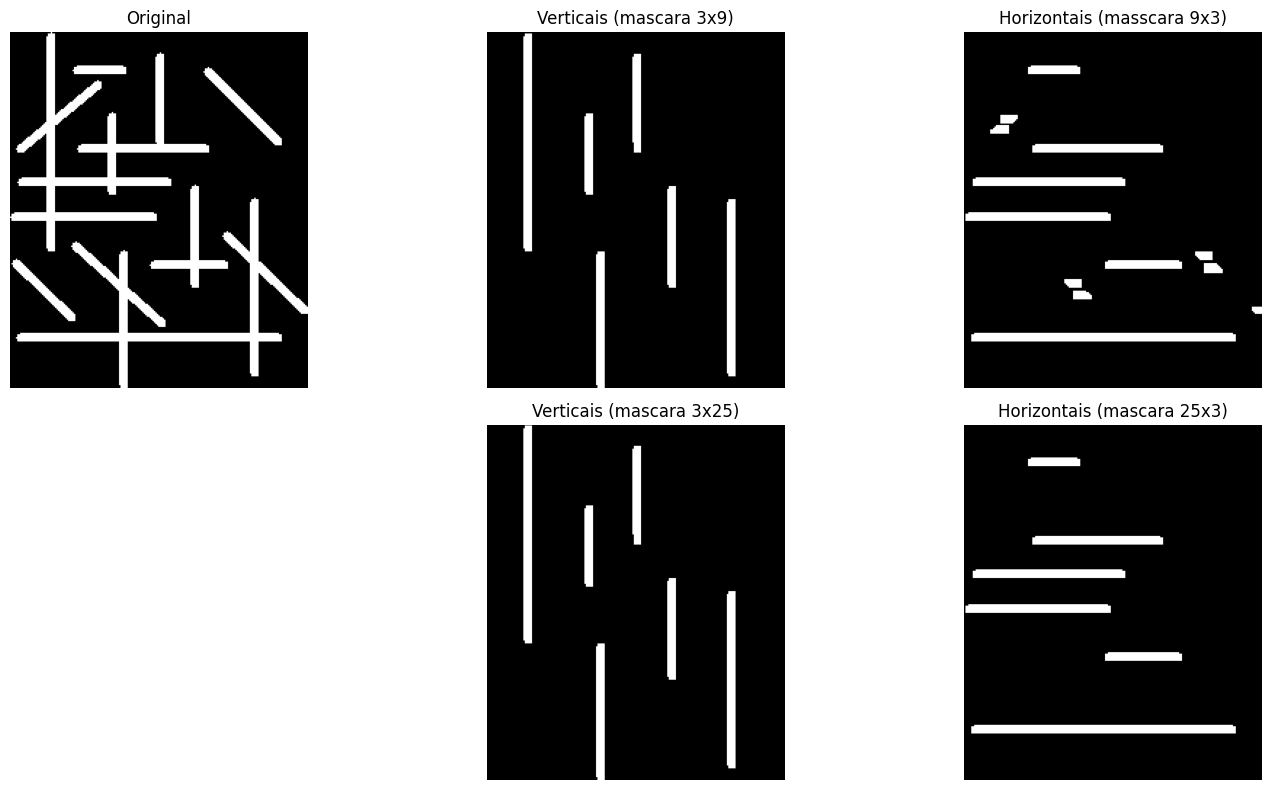

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img2 = cv2.imread("art2.png", cv2.IMREAD_GRAYSCALE)

# --- RESOLUCAO DO ITEM A (Linhas Verticais) ---
kernel_vert = np.ones((9, 3), dtype=np.uint8)
img_verticais = cv2.morphologyEx(img2, cv2.MORPH_OPEN, kernel_vert)

# --- RESOLUCAO DO ITEM B (Linhas Horizontais) ---

kernel_horiz = np.ones((3, 9), dtype=np.uint8)
img_horizontais = cv2.morphologyEx(img2, cv2.MORPH_OPEN, kernel_horiz)

# --- MASCARA MAIOR ---

kernel_vert_maior = np.ones((25, 3), dtype=np.uint8)
kernel_horiz_maior = np.ones((3, 25), dtype=np.uint8)

img_verticais_limpas = cv2.morphologyEx(img2, cv2.MORPH_OPEN, kernel_vert_maior)
img_horizontais_limpas = cv2.morphologyEx(img2, cv2.MORPH_OPEN, kernel_horiz_maior)


# --- PLOTANDO OS RESULTADOS PRA COMPARAR ---
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(img2, cmap='gray')
plt.title("Original")
plt.axis('off')


plt.subplot(2, 3, 2)
plt.imshow(img_verticais, cmap='gray')
plt.title("Verticais (mascara 3x9)")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(img_horizontais, cmap='gray')
plt.title("Horizontais (masscara 9x3)")
plt.axis('off')


plt.subplot(2, 3, 5)
plt.imshow(img_verticais_limpas, cmap='gray')
plt.title("Verticais (mascara 3x25)")
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(img_horizontais_limpas, cmap='gray')
plt.title("Horizontais (mascara 25x3)")
plt.axis('off')

plt.tight_layout()
plt.show()


a) Theshold (t=210)

b) Utilizando abertura com elemento circular de 11 pixels para reter as células grandes

c) É possível reter somente os objetos pequenos utilizando a operação abertura?

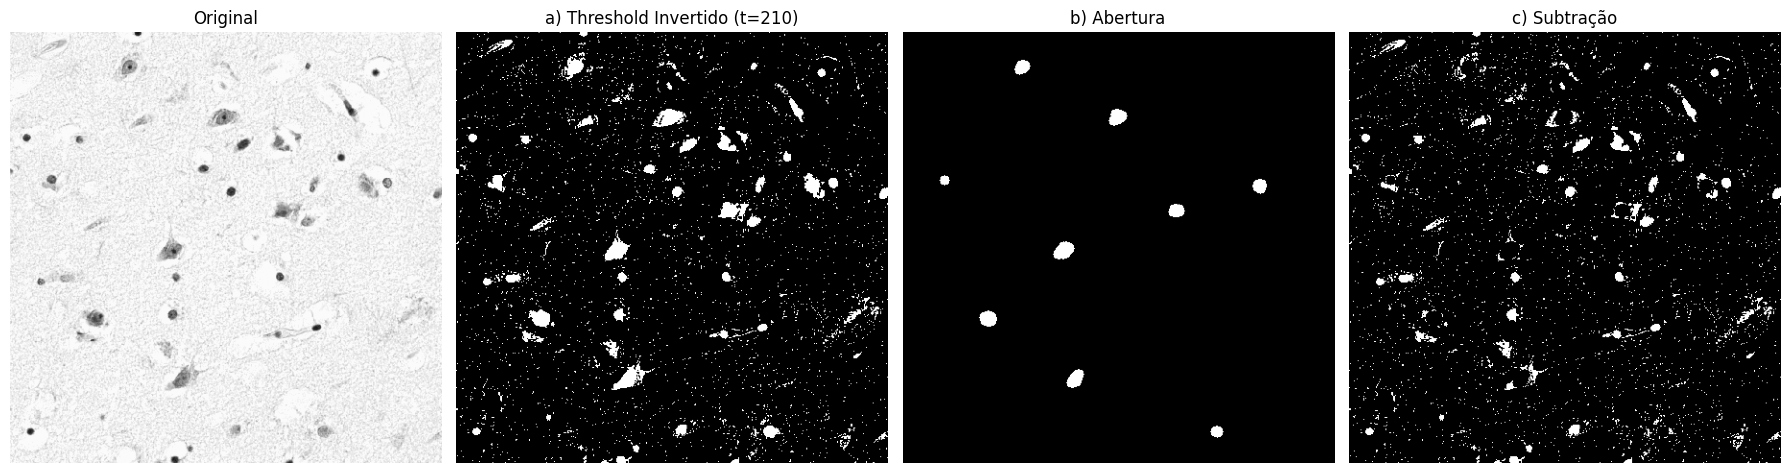

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img3 = cv2.imread("cel4.png", cv2.IMREAD_GRAYSCALE)
if img3 is None:
    raise ValueError("Imagem não encontrada!")

# --- a) Threshold (t=210) ---
_, img_bin = cv2.threshold(img3, 210, 255, cv2.THRESH_BINARY_INV)

# --- b) elemento circular
def criar_kernel_circular(raio):
    tamanho = 2 * raio + 1
    kernel = np.zeros((tamanho, tamanho), dtype=np.uint8)
    for i in range(tamanho):
        for j in range(tamanho):
            if (i - raio)**2 + (j - raio)**2 <= raio**2:
                kernel[i, j] = 1
    return kernel


kernel_11px = criar_kernel_circular(5)


img_celulas_grandes = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, kernel_11px)

# --- c) objetos pequenos ---
img_celulas_pequenas = cv2.subtract(img_bin, img_celulas_grandes)


# --- Plotando todos os passos ---
plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.imshow(img3, cmap='gray', vmin=0, vmax=255)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_bin, cmap='gray', vmin=0, vmax=255)
plt.title("a) Threshold Invertido (t=210)")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_celulas_grandes, cmap='gray', vmin=0, vmax=255)
plt.title("b) Abertura")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_celulas_pequenas, cmap='gray', vmin=0, vmax=255)
plt.title("c) Subtração")
plt.axis('off')

plt.tight_layout()
plt.show()

:Utilizando os conceitos já aprendidos na disciplina, faça um código que calcula a quantidade de objetos da imagem abaixo. Pode-se utilizar funções prontas do opencv (não para realizar a contagem em si, mas para realizar os passos necessários)

Quantidade de feijpeses encontrados: 70


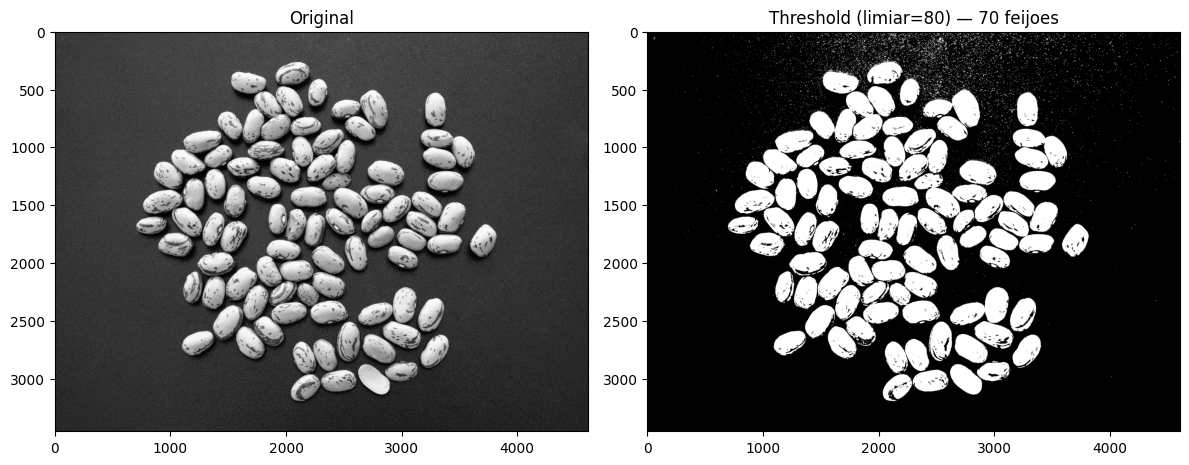

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img4 = cv2.imread("feijao.jpg", cv2.IMREAD_GRAYSCALE)
if img4 is None:
    raise ValueError("A imagem não foi encontrada!")

# 2. Binarização
_, thresh = cv2.threshold(img4, 80, 255, cv2.THRESH_BINARY)


img_trabalho = thresh.copy()
linhas, colunas = img_trabalho.shape

contagem_feijoes = 0
area_minima = 5000


for i in range(linhas):
    for j in range(colunas):
        if img_trabalho[i, j] == 255:
            pilha = [(i, j)]
            img_trabalho[i, j] = 0
            area_atual = 1
            while pilha:
                y, x = pilha.pop()
                vizinhos = [(y-1, x), (y+1, x), (y, x-1), (y, x+1)]
                for vy, vx in vizinhos:
                    if 0 <= vy < linhas and 0 <= vx < colunas:
                        if img_trabalho[vy, vx] == 255:
                            img_trabalho[vy, vx] = 0
                            area_atual += 1
                            pilha.append((vy, vx))
            if area_atual > area_minima:
                contagem_feijoes += 1

print(f"Quantidade de feijpeses encontrados: {contagem_feijoes}")

# 5. Plotar os resultados
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(img4, cmap='gray', vmin=0, vmax=255)
axs[0].set_title("Original")

axs[1].imshow(thresh, cmap='gray')
axs[1].set_title(f"Threshold (limiar=80) — {contagem_feijoes} feijoes")

plt.tight_layout()
plt.show()

Utilize a transformada hit or miss para localizar o logotipo da UFU. Escolha um deles

Logos UFU encontrados no total: 4


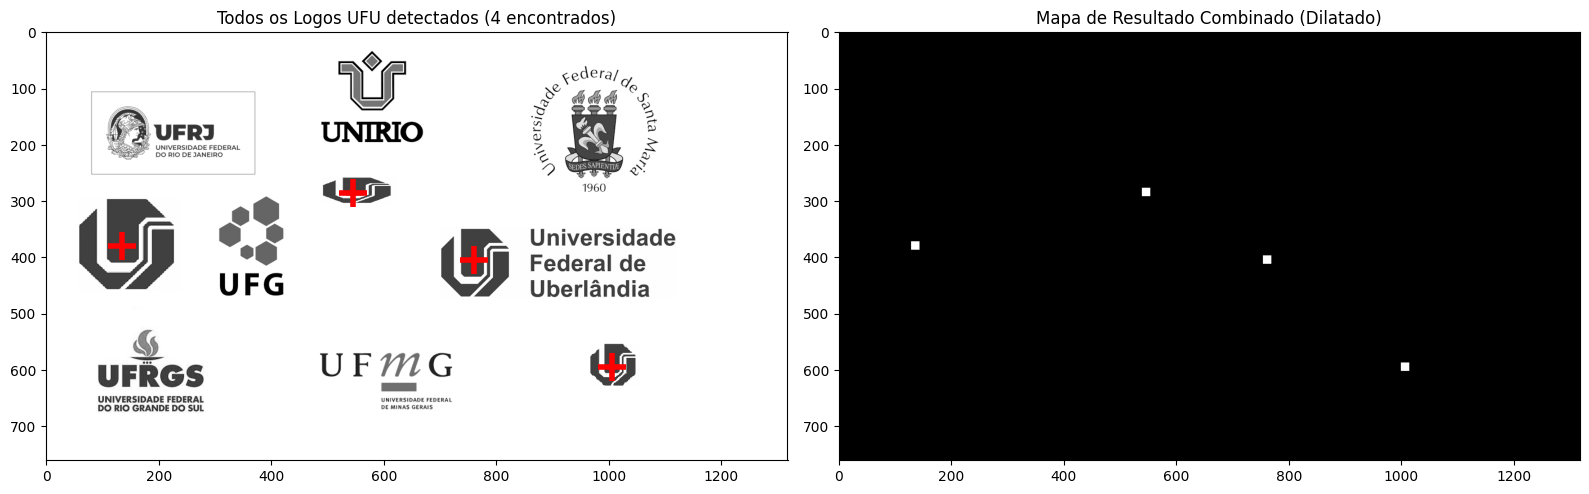

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img5 = cv2.imread("logotipos.png", cv2.IMREAD_GRAYSCALE)

# Binarização
_, img_bin = cv2.threshold(img5, 127, 255, cv2.THRESH_BINARY_INV)

# --- PASSO 1: RECORTAR OS MOLDES DA UFU ---
# As coordenadas
template_pequeno = img_bin[550:640, 960:1050]
template_gigante = img_bin[280:480, 30:240]
template_achatado = img_bin[250:320, 480:610]
template_medio = img_bin[330:480, 690:830]


def criar_kernel_hitmiss(template):
    kernel = np.zeros(template.shape, dtype=np.int8)
    kernel[template == 255] = 1
    kernel[template == 0] = -1
    return kernel

kernel_peq = criar_kernel_hitmiss(template_pequeno)
kernel_gig = criar_kernel_hitmiss(template_gigante)
kernel_ach = criar_kernel_hitmiss(template_achatado)
kernel_med = criar_kernel_hitmiss(template_medio)


# --- PASSO 2: HIT-OR-MISS ---
resultado_peq = cv2.morphologyEx(img_bin, cv2.MORPH_HITMISS, kernel_peq)
resultado_gig = cv2.morphologyEx(img_bin, cv2.MORPH_HITMISS, kernel_gig)
resultado_ach = cv2.morphologyEx(img_bin, cv2.MORPH_HITMISS, kernel_ach)
resultado_med = cv2.morphologyEx(img_bin, cv2.MORPH_HITMISS, kernel_med)

# --- PASSO 3: RESULTADOS ---
resultado_final = cv2.bitwise_or(resultado_peq, resultado_gig)
resultado_final = cv2.bitwise_or(resultado_final, resultado_ach)
resultado_final = cv2.bitwise_or(resultado_final, resultado_med)


pontos = list(zip(*np.where(resultado_final == 255)))
print(f"Logos UFU encontrados no total: {len(pontos)}")

# --- PLOT ---
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].imshow(img5, cmap='gray')
for (py, px) in pontos:
    axs[0].plot(px, py, 'r+', markersize=20, markeredgewidth=4)
axs[0].set_title(f"Todos os Logos UFU detectados ({len(pontos)} encontrados)")

# Dilatamos os 3 pontinhos só para eles ficarem visíveis a olho nu no gráfico do lado direito
resultado_visivel = cv2.dilate(resultado_final, np.ones((15, 15), np.uint8))
axs[1].imshow(resultado_visivel, cmap='gray')
axs[1].set_title("Mapa de Resultado Combinado (Dilatado)")

plt.tight_layout()
plt.show()

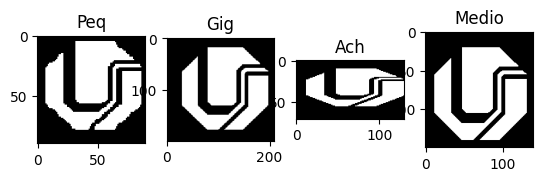

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img5 = cv2.imread("logotipos.png", cv2.IMREAD_GRAYSCALE)

# Binarização
_, img_bin = cv2.threshold(img5, 127, 255, cv2.THRESH_BINARY_INV)

# As coordenadas
template_pequeno = img_bin[550:640, 960:1050]
template_gigante = img_bin[280:480, 30:240]
template_achatado = img_bin[250:320, 480:610]
template_medio = img_bin[330:480, 690:830]

fig, ax = plt.subplots(1,4)
ax[0].imshow(template_pequeno, cmap='gray'); ax[0].set_title("Peq")
ax[1].imshow(template_gigante, cmap='gray'); ax[1].set_title("Gig")
ax[2].imshow(template_achatado, cmap='gray'); ax[2].set_title("Ach")
ax[3].imshow(template_medio, cmap='gray'); ax[3].set_title("Medio")
plt.show()

Utilize operadores morfológicos para extração de fronteiras dos feijões. Mostre o resultado junto com a imagem original


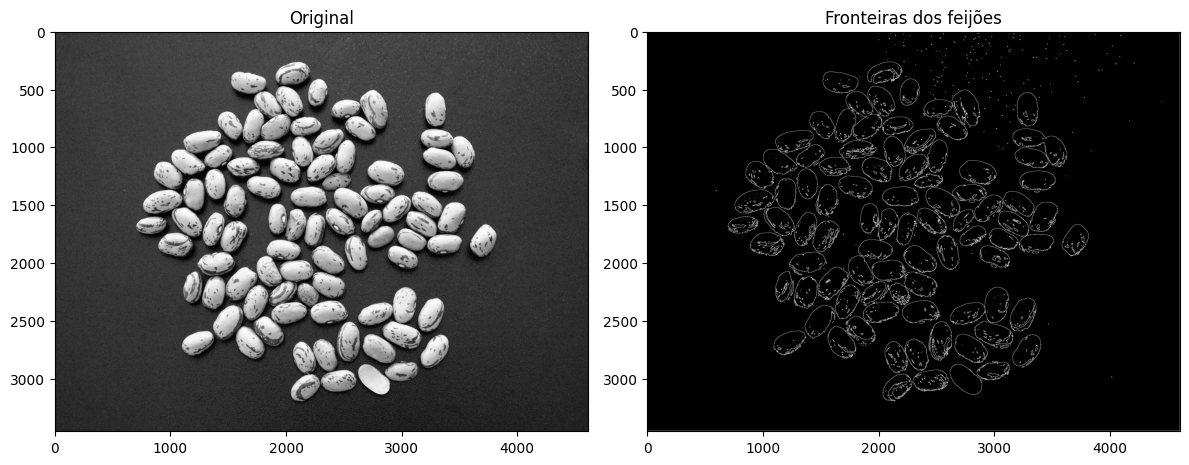

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("feijao.jpg", cv2.IMREAD_GRAYSCALE)

# Binarização
h, w = img.shape
img_bin = np.zeros((h, w), dtype=np.uint8)
for y in range(h):
    for x in range(w):
        if img[y, x] < 127:
            img_bin[y, x] = 1
        else:
            img_bin[y, x] = 0

# Erosão
def erosao(img, kernel_size=3):
    h, w = img.shape
    pad = kernel_size // 2
    resultado = np.zeros_like(img)
    for y in range(pad, h - pad):
        for x in range(pad, w - pad):
            janela = img[y-pad:y+pad+1, x-pad:x+pad+1]
            resultado[y, x] = 1 if np.all(janela == 1) else 0
    return resultado

# Fronteira = imagem original - erosão
img_erodida = erosao(img_bin, kernel_size=5)
fronteira = img_bin - img_erodida

# Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axs[0].set_title("Original")
axs[1].imshow(fronteira, cmap='gray')
axs[1].set_title("Fronteiras dos feijões")
plt.tight_layout()
plt.show()